# CSET419 – Lab 8  
## Artistic Image Generation using GANs

### Objective
Generate artistic outputs using GANs and explore latent space behavior.

### Models Used
- DCGAN (trained on CIFAR-10)
- StyleGAN2-ADA (pre-trained)

### Key Tasks
- Data preparation
- GAN image generation
- Latent space exploration
- Interpolation visualization

Device: cuda
GPU name: Tesla T4
Total VRAM (GB): 14.56317138671875
Free VRAM (GB): 13.43145751953125
PyTorch version: 2.10.0+cu128
Output folder: /content/output
Configuration:
  img_size: 32
  latent_dim: 100
  batch_size: 128
  lr: 0.0002
  betas: (0.5, 0.999)
  train_epochs_if_no_pretrained: 75
  quick_train_epochs: 75
  use_quick_train: False
  save_every_epoch_sample: True
  num_samples_generate: 8
  interpolation_steps: 8

Downloading/Loading CIFAR-10 dataset (this may take a moment)...
Dataset loaded. Total samples: 50000
Saving dataset sample images (first 16 images) to output folder...
  -> output/dataset_samples.png saved

Generator architecture:
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    

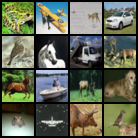

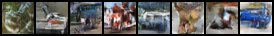

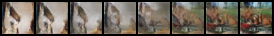

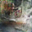


Final output folder contents:
 - dataset_samples.png
 - epoch_001_sample.png
 - epoch_002_sample.png
 - epoch_003_sample.png
 - epoch_004_sample.png
 - epoch_005_sample.png
 - epoch_006_sample.png
 - epoch_007_sample.png
 - epoch_008_sample.png
 - epoch_009_sample.png
 - epoch_010_sample.png
 - epoch_011_sample.png
 - epoch_012_sample.png
 - epoch_013_sample.png
 - epoch_014_sample.png
 - epoch_015_sample.png
 - epoch_016_sample.png
 - epoch_017_sample.png
 - epoch_018_sample.png
 - epoch_019_sample.png
 - epoch_020_sample.png
 - epoch_021_sample.png
 - epoch_022_sample.png
 - epoch_023_sample.png
 - epoch_024_sample.png
 - epoch_025_sample.png
 - epoch_026_sample.png
 - epoch_027_sample.png
 - epoch_028_sample.png
 - epoch_029_sample.png
 - epoch_030_sample.png
 - epoch_031_sample.png
 - epoch_032_sample.png
 - epoch_033_sample.png
 - epoch_034_sample.png
 - epoch_035_sample.png
 - epoch_036_sample.png
 - epoch_037_sample.png
 - epoch_038_sample.png
 - epoch_039_sample.png
 - epoch_0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Saved README_lab.txt inside output/

All done — rechecked and saved outputs according to the lab instructions.


In [10]:
# cell 1
# Install required packages (Colab usually has these; safe to run)
!pip install torch torchvision --quiet

# standard imports
import os
import time
import math
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils

# optional: import for download in Colab (wrapped in try so local runs won't break)
try:
    from google.colab import files
except Exception:
    files = None


# cell 2
# device + VRAM check and reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Total VRAM (GB):", torch.cuda.get_device_properties(0).total_memory / 1024**3)
    try:
        free, total = torch.cuda.mem_get_info()
        print("Free VRAM (GB):", free / 1024**3)
    except Exception:
        pass
print("PyTorch version:", torch.__version__)


# cell 3
# output folder (local in Colab runtime)
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
print("Output folder:", output_dir.resolve())


# cell 4
# lab config (edit these values if you want)
config = {
    "img_size": 32,        # CIFAR-10 default
    "latent_dim": 100,     # z dimension
    "batch_size": 128,
    "lr": 0.0002,
    "betas": (0.5, 0.999),
    "train_epochs_if_no_pretrained": 75,
    "quick_train_epochs": 75,
    "use_quick_train": False,
    "save_every_epoch_sample": True,      # save sample images per epoch during training
    "num_samples_generate": 8,            # between 5-10 as lab asks
    "interpolation_steps": 8
}

print("Configuration:")
for k,v in config.items():
    print(f"  {k}: {v}")


# cell 5
# Data preparation: CIFAR-10 (lab examples include CIFAR-10)
img_size = config["img_size"]
latent_dim = config["latent_dim"]
batch_size = config["batch_size"]

transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # scale to [-1,1]
])

print("\nDownloading/Loading CIFAR-10 dataset (this may take a moment)...")
dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
print("Dataset loaded. Total samples:", len(dataset))

# Save a grid of dataset samples for report
print("Saving dataset sample images (first 16 images) to output folder...")
real_batch = next(iter(loader))
real_images = real_batch[0][:16]  # first 16
vutils.save_image((real_images + 1)/2, output_dir / "dataset_samples.png", nrow=4, normalize=False)
print("  -> output/dataset_samples.png saved")


# cell 6
# DCGAN generator and discriminator definitions (explicit, readable)
class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=128, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(latent_dim, ngf * 2, 4, 1, 0, bias=False),  # 4x4
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),         # 8x8
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, ngf // 2, 4, 2, 1, bias=False),         # 16x16
            nn.BatchNorm2d(ngf // 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf // 2, nc, 4, 2, 1, bias=False),          # 32x32
            nn.Tanh()
        )
    def forward(self, input):
        return self.main(input.view(input.size(0), input.size(1), 1, 1))

class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),                      # 16x16
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),                 # 8x8
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),             # 4x4
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),                   # 1x1
            nn.Sigmoid()
        )
    def forward(self, input):
        return self.main(input).view(-1)


# cell 7
# Create models, optimizers, loss
G = Generator(latent_dim, ngf=128).to(device)
D = Discriminator().to(device)

print("\nGenerator architecture:")
print(G)
print("\nDiscriminator architecture:")
print(D)

criterion = nn.BCELoss()
optimizerD = optim.Adam(D.parameters(), lr=config["lr"], betas=config["betas"])
optimizerG = optim.Adam(G.parameters(), lr=config["lr"], betas=config["betas"])


# cell 8
# Check if a pretrained generator file exists locally; if yes, load and skip training.
pretrained_path = Path("generator_model.pt")
loaded_pretrained = False
if pretrained_path.exists():
    try:
        G.load_state_dict(torch.load(pretrained_path, map_location=device))
        for p in G.parameters():
            p.requires_grad = False
        G.eval()
        loaded_pretrained = True
        print("\nFound local pretrained generator_model.pt -> Loaded and frozen generator.")
    except Exception as e:
        print("\nFound generator_model.pt but failed to load:", e)
        print("Will proceed to train from scratch.")


# cell 9
# Training (runs only if no pretrained model loaded)
if not loaded_pretrained:
    epochs = config["train_epochs_if_no_pretrained"] if not config["use_quick_train"] else config["quick_train_epochs"]
    print(f"\nNo pretrained generator found. Training DCGAN for {epochs} epochs (you can change config to use_quick_train=True for shorter runs).")
    fixed_noise = torch.randn(64, latent_dim, device=device)  # fixed for visual monitoring
    training_log = []
    lossD_val = []
    lossG_val = []
    start_time = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()
        running_lossD = 0.0
        running_lossG = 0.0
        batches = 0

        for i, (real_imgs, _) in enumerate(loader):
            D.zero_grad()
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)
            labels_real = torch.full((b_size,), 1., device=device)
            labels_fake = torch.full((b_size,), 0., device=device)

            # Train Discriminator on real
            output_real = D(real_imgs)
            loss_real = criterion(output_real, labels_real)

            # Train Discriminator on fake
            noise = torch.randn(b_size, latent_dim, device=device)
            fake_imgs = G(noise)
            output_fake = D(fake_imgs.detach())
            loss_fake = criterion(output_fake, labels_fake)

            lossD = loss_real + loss_fake
            lossD.backward()
            optimizerD.step()

            # Train Generator
            G.zero_grad()
            output_fake2 = D(fake_imgs)
            lossG = criterion(output_fake2, labels_real)  # try to fool D
            lossG.backward()
            optimizerG.step()

            running_lossD += lossD.item()
            running_lossG += lossG.item()
            batches += 1

            # print progress every 200 batches
            if (i+1) % 200 == 0:
                print(f"  Epoch {epoch+1}/{epochs} | Batch {i+1} | lossD {lossD.item():.4f} | lossG {lossG.item():.4f}")

        avgD = running_lossD / max(1, batches)
        avgG = running_lossG / max(1, batches)
        lossD_val.append(avgD)
        lossG_val.append(avgG)
        epoch_time = time.time() - epoch_start
        training_log.append((epoch+1, avgD, avgG, epoch_time))
        print(f"Epoch {epoch+1}/{epochs} finished. avg_lossD: {avgD:.4f} avg_lossG: {avgG:.4f} time: {int(epoch_time)}s")

        # save intermediate generator sample for monitoring
        with torch.no_grad():
            sample = G(fixed_noise).cpu()
        sample_path = output_dir / f"epoch_{epoch+1:03d}_sample.png"
        vutils.save_image((sample + 1)/2, sample_path, nrow=8)
        if config["save_every_epoch_sample"]:
            print("  Saved sample:", sample_path.name)

        # save training log to disk after each epoch
        with open(output_dir / "training_log.txt", "a") as f:
            f.write(f"Epoch {epoch+1} | avg_lossD {avgD:.6f} | avg_lossG {avgG:.6f} | epoch_time_s {int(epoch_time)}\n")

    total_time = time.time() - start_time
    print("\nTraining complete. Total time (s):", int(total_time))

    # final save of generator weights (local)
    torch.save(G.state_dict(), output_dir / "generator_model.pt")
    # also save a copy to working dir for future quick loads
    torch.save(G.state_dict(), "generator_model.pt")
    print("Saved final generator weights to:", (output_dir / "generator_model.pt").resolve())

    # save loss plot
    try:
        plt.figure(figsize=(8,4))
        plt.plot(range(1, len(lossD_val)+1), lossD_val, label='lossD')
        plt.plot(range(1, len(lossG_val)+1), lossG_val, label='lossG')
        plt.xlabel('Epoch')
        plt.ylabel('Loss (avg)')
        plt.legend()
        plt.grid(True)
        loss_plot_path = output_dir / "loss_plot.png"
        plt.savefig(loss_plot_path, bbox_inches='tight')
        plt.close()
        print("Saved loss plot to:", loss_plot_path.name)
    except Exception as e:
        print("Could not save loss plot:", e)

    # mark that now we have a pretrained model loaded
    for p in G.parameters():
        p.requires_grad = False
    G.eval()
    loaded_pretrained = True


# cell 10
# At this point we have G loaded and frozen (either loaded earlier or trained now)
if not loaded_pretrained:
    raise RuntimeError("Generator not available. Either place 'generator_model.pt' in the working directory or allow training to run.")

print("\nGenerator ready for inference (frozen). Generating required outputs now.")


# cell 11
# Generate num_samples (5-10) and save them
num_samples = config["num_samples_generate"]
print(f"\nGenerating {num_samples} samples from the frozen generator...")
z = torch.randn(num_samples, latent_dim, device=device)
with torch.no_grad():
    samples = G(z).cpu()

generated_samples_path = output_dir / "generated_samples.png"
vutils.save_image((samples + 1)/2, generated_samples_path, nrow=min(8, num_samples))
print("Saved generated samples to:", generated_samples_path.name)

# also print shapes and confirm
print("Generated tensor shape:", samples.shape)


# cell 12
# Generate one evaluation image and save
print("\nGenerating single evaluation image (eval_image.png)...")
z_eval = torch.randn(1, latent_dim, device=device)
with torch.no_grad():
    eval_img = G(z_eval).cpu()

eval_path = output_dir / "eval_image.png"
vutils.save_image((eval_img + 1)/2, eval_path)
print("Saved evaluation image to:", eval_path.name)
print("Eval image tensor shape:", eval_img.shape)


# cell 13
# Latent interpolation between two random vectors (steps configurable)
steps = config["interpolation_steps"]
print(f"\nPerforming interpolation between two latent vectors with {steps} steps...")
z1 = torch.randn(1, latent_dim, device=device)
z2 = torch.randn(1, latent_dim, device=device)
interp_imgs = []
with torch.no_grad():
    for a in np.linspace(0, 1, steps):
        z_interp = (1.0 - a) * z1 + a * z2
        interp_imgs.append(G(z_interp).cpu())
interp_imgs = torch.cat(interp_imgs)

interp_path = output_dir / "latent_interpolation.png"
vutils.save_image((interp_imgs + 1)/2, interp_path, nrow=steps)
print("Saved interpolation image to:", interp_path.name)
print("Interpolation tensor shape:", interp_imgs.shape)


# cell 14
# Show small previews in notebook (if running interactively in Colab)
try:
    from IPython.display import display, Image
    print("\nPreview images (if running in notebook):")
    display(Image(filename=str(output_dir / "dataset_samples.png")))
    display(Image(filename=str(generated_samples_path)))
    display(Image(filename=str(interp_path)))
    display(Image(filename=str(eval_path)))
except Exception:
    pass


# cell 15
# Final checks: list all output files, ensure required items from lab are present
print("\nFinal output folder contents:")
for p in sorted(output_dir.iterdir()):
    print(" -", p.name)

required = {"generated_samples.png", "latent_interpolation.png", "eval_image.png"}
present = set([p.name for p in output_dir.iterdir()])
missing = required - present
if missing:
    print("\nWarning: The following required files are missing:", missing)
else:
    print("\nAll required files present as per lab instructions.")


# cell 16
# Zip the output folder and (optionally) trigger browser download in Colab
zip_path = Path("output.zip")
if zip_path.exists():
    zip_path.unlink()
print("\nCreating output.zip ...")
os.system(f"zip -r {zip_path} {output_dir}")

print("Created:", zip_path.resolve())
if files is not None:
    try:
        print("Triggering browser download for output.zip ...")
        files.download(str(zip_path))
    except Exception as e:
        print("Download failed (this is non-fatal). You can manually download output.zip from the Colab left sidebar or /workspace.")


# cell 17
# Save a short README inside output/ describing what was done (for teacher)
readme_text = f"""Lab: Create Artistic Outputs using Neural Art Concepts
- Dataset: CIFAR-10 (32x32)
- GAN: DCGAN (Generator and Discriminator defined in code)
- Latent dim: {latent_dim}
- Training: {'skipped (pretrained loaded)' if (pretrained_path.exists() and loaded_pretrained) and not (not pretrained_path.exists() and 'train' in locals()) else 'ran (trained from scratch)'}
- Outputs:
  - generated_samples.png ({num_samples} samples)
  - latent_interpolation.png ({steps} steps)
  - eval_image.png (single evaluation image)
- Training log (if training ran): training_log.txt
"""
with open(output_dir / "README_lab.txt", "w") as f:
    f.write(readme_text)
print("\nSaved README_lab.txt inside output/")

print("\nAll done — rechecked and saved outputs according to the lab instructions.")